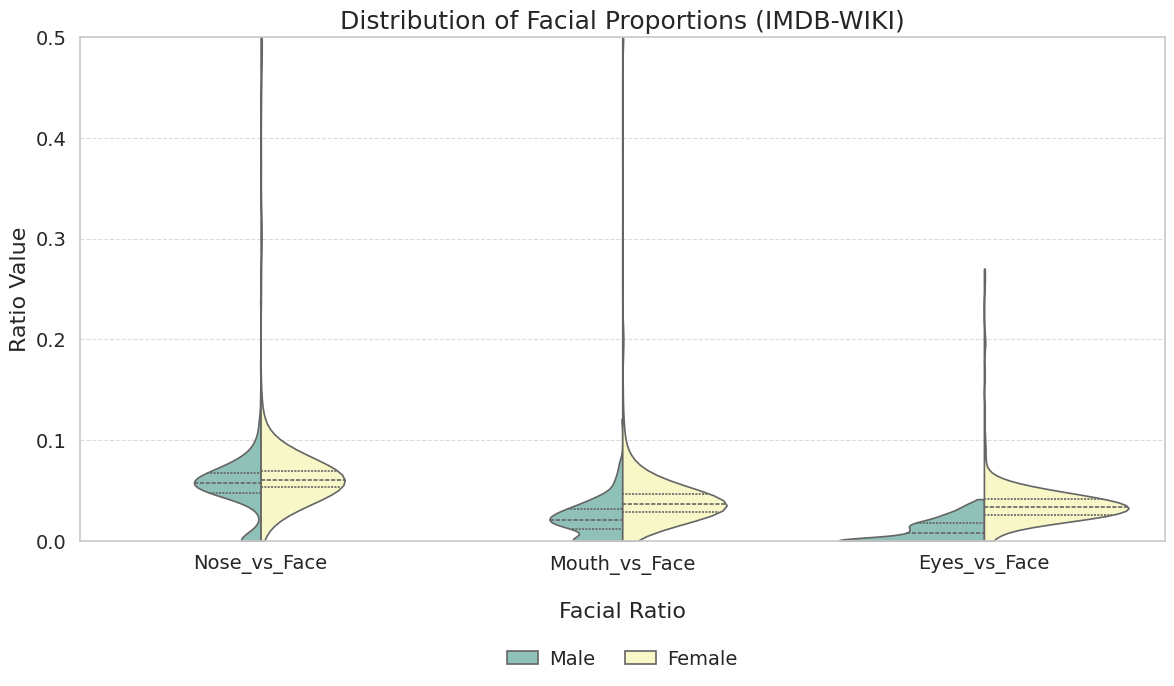

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# 0. GLOBAL FONT SETTINGS (LARGER)
# =========================================================
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 22,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14
})

# =========================================================
# 1. Load CSV
# =========================================================
df = pd.read_csv("facial_proportions_wiki_imdb.csv")

# =========================================================
# 2. Convert to long format
# =========================================================
cols_to_plot = [
    "Nose_vs_Face",
    "Mouth_vs_Face",
    "Eyes_vs_Face",
]

df_long = pd.melt(
    df,
    id_vars=["gender"],
    value_vars=cols_to_plot,
    var_name="Ratio Type",
    value_name="Value"
)



# =========================================================
# 4. Plot
# =========================================================
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(14, 8))

colors = {"Male": "#88c9bf", "Female": "#ffffbf"}

sns.violinplot(
    data=df_long,
    x="Ratio Type",
    y="Value",
    hue="gender",
    split=True,
    inner="quart",
    palette=colors,
    linewidth=1.2,
    cut=0,
    ax=ax
)

ax.set_title("Distribution of Facial Proportions (IMDB-WIKI)", fontsize=18)
ax.set_xlabel("Facial Ratio", fontsize=16, labelpad=20)
ax.set_ylabel("Ratio Value", fontsize=16)
ax.tick_params(axis="x", labelsize=14)
ax.tick_params(axis="y", labelsize=14)
ax.set_ylim(0, 0.5)

# =========================================================
# 5. GRID (SUBTLE)
# =========================================================
ax.grid(True, axis="y", linestyle="--", linewidth=0.8, alpha=0.7)

# =========================================================
# 6. LEGEND — HORIZONTAL BELOW X LABEL
# =========================================================
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=False,
    handlelength=1.6,
    handletextpad=0.6,
    columnspacing=1.5,
    fontsize=14
)

# =========================================================
# 7. Layout
# =========================================================
plt.subplots_adjust(bottom=0.25)
plt.show()


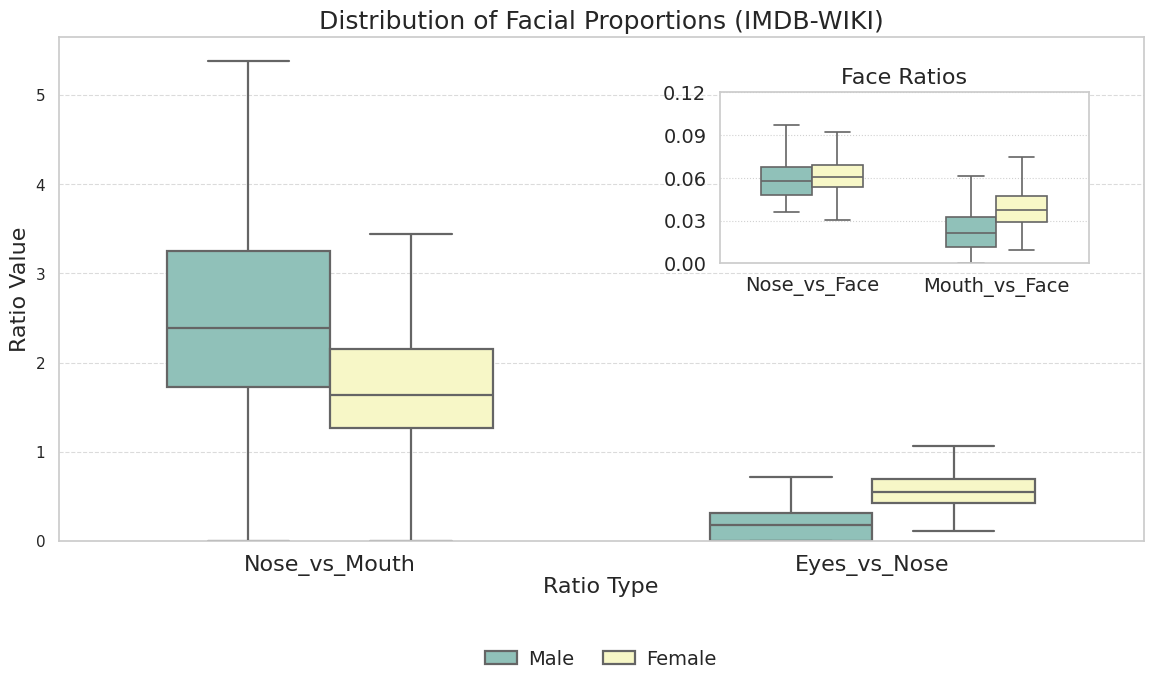

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import FormatStrFormatter

# =========================================================
# 0. GLOBAL FONT SETTINGS
# =========================================================
plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 22,
    "axes.labelsize": 18,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "legend.fontsize": 14
})

# =========================================================
# 1. Load data
# =========================================================
df = pd.read_csv("facial_proportions_wiki_imdb.csv")

# =========================================================
# 2. Ratio groups
# =========================================================
face_ratios = ["Nose_vs_Face", "Mouth_vs_Face"]
cross_ratios = ["Nose_vs_Mouth", "Eyes_vs_Nose"]

# =========================================================
# 3. Convert to long format
# =========================================================
df_long = pd.melt(
    df,
    id_vars=["gender"],
    value_vars=face_ratios + cross_ratios,
    var_name="Ratio_Type",
    value_name="Value"
)



# =========================================================
# 5. Style
# =========================================================
sns.set_theme(style="whitegrid")
palette = {"Male": "#88c9bf", "Female": "#ffffbf"}

# =========================================================
# 6. Main plot
# =========================================================
fig, ax = plt.subplots(figsize=(14, 8))

sns.boxplot(
    data=df_long[df_long["Ratio_Type"].isin(cross_ratios)],
    x="Ratio_Type",
    y="Value",
    hue="gender",
    palette=palette,
    showfliers=False,
    linewidth=1.6,
    width=0.6,
    order=cross_ratios,
    ax=ax
)

ax.set_title("Distribution of Facial Proportions (IMDB-WIKI)", fontsize=18)
ax.set_xlabel("Ratio Type", fontsize=16, labelpad=1)
ax.set_ylabel("Ratio Value", fontsize=16)
ax.tick_params(axis="x", rotation=0, labelsize = 16)
ax.set_ylim(bottom=0.0)

# Grid main plot
ax.grid(True, axis="y", linestyle="--", linewidth=0.8, alpha=0.7)

# =========================================================
# 7. LEGEND — BELOW "Ratio Type", HORIZONTAL
# =========================================================
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    frameon=False,
    handlelength=1.6,
    handletextpad=0.6,
    columnspacing=1.5,
    fontsize=14
)

# =========================================================
# 8. Inset plot
# =========================================================
inset_ax = inset_axes(
    ax,
    width="34%",
    height="34%",
    loc="upper right",
    borderpad=3.6
)

sns.boxplot(
    data=df_long[df_long["Ratio_Type"].isin(face_ratios)],
    x="Ratio_Type",
    y="Value",
    hue="gender",
    palette=palette,
    showfliers=False,
    linewidth=1.2,
    width=0.55,
    order=face_ratios,
    ax=inset_ax
)

# =========================================================
# 9. Inset formatting + GRID
# =========================================================
inset_ax.set_ylim(0.0, 0.12)
inset_ax.set_yticks([0.00, 0.03, 0.06, 0.09, 0.12])
inset_ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

inset_ax.set_title("Face Ratios", fontsize=16)
inset_ax.set_xlabel("")
inset_ax.set_ylabel("")
inset_ax.tick_params(axis="x", labelsize=14)
inset_ax.tick_params(axis="y", labelsize=14)

inset_ax.set_axisbelow(True)
inset_ax.grid(
    True,
    axis="y",
    linestyle=":",
    linewidth=0.8,
    alpha=0.9
)

# Remove legend inside inset
if inset_ax.get_legend() is not None:
    inset_ax.get_legend().remove()

# =========================================================
# 10. Layout (EXTRA SPACE FOR LEGEND)
# =========================================================
plt.subplots_adjust(bottom=0.25)
plt.show()


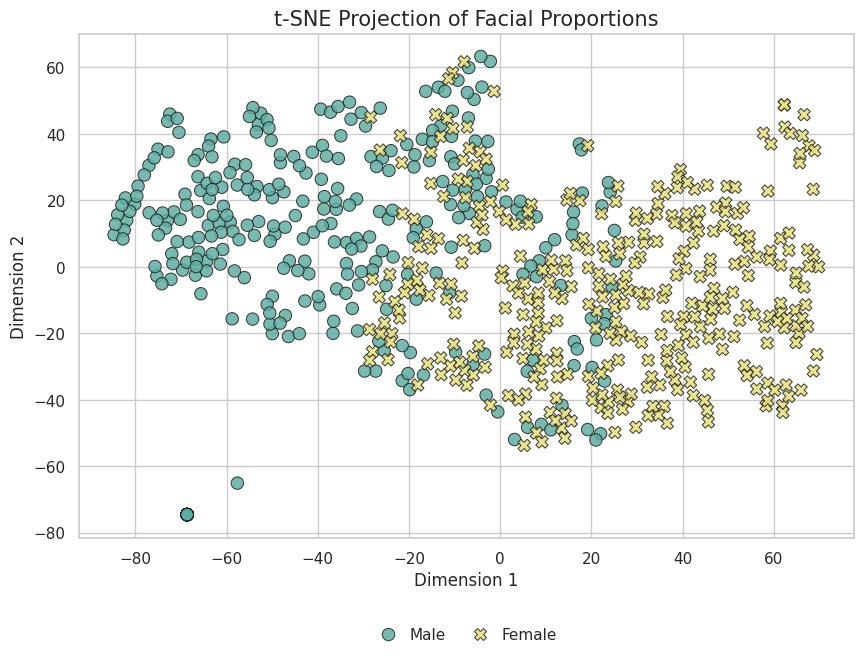

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# ============================================================
# 1. Load  Data
# ============================================================
try:
    df = pd.read_csv("facial_proportions_wiki_imdb.csv")

    # ============================================================
    # 2. Plot
    # ============================================================
    sns.set_theme(style="whitegrid")

    fig, ax = plt.subplots(figsize=(10, 8))

    palette = {
        "Male": "#5faea3",
        "Female": "#e6e07a"
    }

    sns.scatterplot(
        data=df,
        x="tsne_x",
        y="tsne_y",
        hue="gender",
        style="gender",
        palette=palette,
        alpha=0.85,
        s=80,
        edgecolor="k",
        ax=ax
    )

    ax.set_title("t-SNE Projection of Facial Proportions", fontsize=15)
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")

    # ============================================================
    # Legend — bottom, horizontal
    # ============================================================
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.15),
        ncol=2,
        frameon=False,
        handlelength=1.6,
        handletextpad=0.6,
        columnspacing=1.5
    )

    plt.subplots_adjust(bottom=0.25)
    plt.show()

except Exception as e:
    print(f"Error: {e}")